# 07 — Practical anomaly detection extension

**Estimated time:** 90–120 minutes  
**Prerequisites:** notebooks 00–03; preprocessing pipelines, validation splits, and ranking metrics.  
**Depends on:** the bundled Bank Marketing dataset. **Optional module.**

## Purpose

Anomaly detection is useful when we need to rank unusual records for review, data-quality checks, or operational investigation. This notebook shows a practical workflow for doing that without pretending that "unusual" automatically means "fraud", "bad data", or the positive class.

## Learning objectives

By the end of this notebook, students should be able to:

- define an anomaly in operational terms;
- keep anomaly preprocessing leakage-safe with scikit-learn pipelines;
- build a simple rule-based baseline before trying model-based detectors;
- compare Isolation Forest and novelty-mode Local Outlier Factor (LOF);
- evaluate ranked alerts with controlled synthetic anomalies and precision@k;
- explain trade-offs among performance, simplicity, speed, and maintainability.

In [1]:
import hashlib, json, os, platform, random, warnings
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
warnings.filterwarnings("ignore", message="X does not have valid feature names, but LGBMClassifier")
warnings.filterwarnings("ignore", message="IProgress not found.*")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (confusion_matrix, log_loss,
                             precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
TARGET = "y"
LEAKAGE_COLUMNS = ["duration"]

def project_root():
    # Return the course root when present, otherwise the notebook's directory.
    return ROOT

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

def fast_mode():
    # Set FAST_MODE=0 for full-size experiments; laptop mode is the default.
    return os.getenv("FAST_MODE", "1").lower() not in {"0", "false", "no"}

def bank_data_path():
    # The course ships with a local dataset; notebooks never access the network.
    path = project_root() / "data" / "raw" / "bank-full.csv"
    if not path.is_file():
        raise FileNotFoundError(
            f"Expected the bundled Bank Marketing data at {path}. "
            "Run the notebook from the course root or place bank-full.csv there."
        )
    return path

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

def load_bank_data(include_duration=False):
    # Load the data, encode y, and exclude post-call duration by default.
    frame = pd.read_csv(bank_data_path(), sep=";")
    frame[TARGET] = frame[TARGET].map({"no": 0, "yes": 1}).astype("int8")
    if not include_duration:
        frame = frame.drop(columns=LEAKAGE_COLUMNS)
    return frame

def stratified_sample(frame, n, seed=SEED):
    if n >= len(frame):
        return frame.copy()
    fractions = frame[TARGET].value_counts(normalize=True)
    counts = (fractions * n).round().astype(int)
    counts.iloc[0] += n - counts.sum()
    parts = [group.sample(n=min(counts.loc[label], len(group)),
                          random_state=seed + int(label))
             for label, group in frame.groupby(TARGET)]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

def make_splits(frame=None, reduced=None):
    # Deterministic stratified 60/20/20 split; test stays sealed until notebook 09.
    from sklearn.model_selection import train_test_split
    frame = load_bank_data() if frame is None else frame
    train_val, test = train_test_split(
        frame, test_size=0.20, stratify=frame[TARGET], random_state=SEED)
    train, validation = train_test_split(
        train_val, test_size=0.25, stratify=train_val[TARGET], random_state=SEED)
    reduced = fast_mode() if reduced is None else reduced
    if reduced:
        train = stratified_sample(train, 12_000)
        validation = stratified_sample(validation, 4_000, SEED + 1)
        test = stratified_sample(test, 4_000, SEED + 2)
    return tuple(part.reset_index(drop=True) for part in (train, validation, test))

def split_xy(frame):
    return frame.drop(columns=TARGET), frame[TARGET]

def feature_groups(frame):
    features = frame.drop(columns=[TARGET], errors="ignore")
    categorical = features.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numerical = features.select_dtypes(include=np.number).columns.tolist()
    return numerical, categorical

def make_preprocessor(frame, scale_numeric=True):
    # Preprocessing is fitted only inside the enclosing training/CV pipeline.
    numerical, categorical = feature_groups(frame)
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                 min_frequency=10, sparse_output=True)),
    ])
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numerical),
        ("categorical", categorical_pipe, categorical),
    ], sparse_threshold=0.3)

def classification_metrics(y_true, probability, threshold=0.5):
    prediction = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {"log_loss": log_loss(y_true, probability),
            "precision": precision_score(y_true, prediction, zero_division=0),
            "recall": recall_score(y_true, prediction, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "cost": float(fp + 5 * fn)}

def threshold_table(y_true, probability, thresholds=None):
    thresholds = np.linspace(0.05, 0.80, 76) if thresholds is None else thresholds
    return pd.DataFrame([{"threshold": float(t),
                          **classification_metrics(y_true, probability, float(t))}
                         for t in thresholds])

def add_domain_features(frame):
    result = frame.copy()
    result["was_previously_contacted"] = (result["pdays"] != -1).astype("int8")
    result["pdays_clean"] = result["pdays"].replace(-1, np.nan)
    result["contact_pressure"] = result["campaign"] / (1 + result["previous"])
    result["balance_per_age"] = result["balance"] / result["age"].clip(lower=18)
    result["age_band"] = pd.cut(result["age"], bins=[0, 29, 39, 49, 59, np.inf],
                                labels=["<30", "30s", "40s", "50s", "60+"]).astype("object")
    return result.drop(columns=["pdays"])

def environment_metadata():
    import sklearn
    return {"python": platform.python_version(), "platform": platform.platform(),
            "numpy": np.__version__, "pandas": pd.__version__,
            "scikit_learn": sklearn.__version__}

def write_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")

set_seed(SEED)
FAST_MODE = fast_mode()
CV_FOLDS = 3 if FAST_MODE else 5
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
print({"FAST_MODE": FAST_MODE, "CV_FOLDS": CV_FOLDS, "seed": SEED})


{'FAST_MODE': True, 'CV_FOLDS': 3, 'seed': 42}


## Concept: what counts as an anomaly?

The Bank Marketing dataset has a subscription label, but it does **not** have verified anomaly, fraud, or data-error labels. In this lesson, an **anomaly** means:

> a row that is unusual under the historical feature distribution and may deserve review.

That definition is intentionally modest. A high anomaly score is an investigation signal, not a decision. Some unusual rows are valid customers, some are data-entry problems, and some may reveal business processes the model does not understand yet.

**Teaching note:** Ask students for examples of rare-but-valid records. Then ask what evidence would be needed before deleting, blocking, or escalating those records.

## Data loading

We use the same local course dataset and deterministic split pattern as earlier notebooks. The sealed test set remains unused; anomaly detection choices should be developed on training and validation data only.

The target column is removed from the anomaly detector inputs. We are modeling unusual feature patterns, not predicting subscription.

In [2]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score
from sklearn.neighbors import LocalOutlierFactor

bank = load_bank_data()
development, validation, _sealed_test = make_splits(bank, reduced=FAST_MODE)

X_dev, y_dev = split_xy(development)
X_val, y_val = split_xy(validation)

print("development shape:", X_dev.shape)
print("validation shape:", X_val.shape)
print("subscription rate in validation:", round(float(y_val.mean()), 3))
X_dev.head()

development shape: (12000, 15)
validation shape: (4000, 15)
subscription rate in validation: 0.117


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome
0,40,blue-collar,married,secondary,no,271,yes,no,unknown,29,may,2,-1,0,unknown
1,56,management,married,tertiary,no,1282,no,no,cellular,19,aug,4,-1,0,unknown
2,56,admin.,divorced,secondary,no,-429,no,yes,cellular,23,jul,4,-1,0,unknown
3,31,self-employed,single,tertiary,no,283,no,no,cellular,28,jan,2,241,1,failure
4,30,management,single,tertiary,no,61,yes,no,telephone,5,may,7,165,5,other


The subscription rate is shown only for orientation. A rare supervised class is not automatically an anomaly class. If the business wants fraud or data-quality detection, it needs a separate outcome definition and review process.

## Preprocessing

Anomaly detectors are sensitive to representation. Numeric scaling and categorical encoding affect distances, partitions, and density estimates.

We will fit preprocessing only on the development split. The validation split simulates future rows. This protects against a common leakage pattern: learning medians, category levels, or scaling parameters from rows we later evaluate.

In [3]:
preprocess = make_preprocessor(X_dev, scale_numeric=True)
feature_names_preview = preprocess.fit(X_dev).get_feature_names_out()[:12]
print("number of transformed features:", len(preprocess.get_feature_names_out()))
print("first transformed feature names:")
for name in feature_names_preview:
    print("-", name)

number of transformed features: 50
first transformed feature names:
- numeric__age
- numeric__balance
- numeric__day
- numeric__campaign
- numeric__pdays
- numeric__previous
- categorical__job_admin.
- categorical__job_blue-collar
- categorical__job_entrepreneur
- categorical__job_housemaid
- categorical__job_management
- categorical__job_retired


For the actual detectors below, preprocessing is placed inside each pipeline. The preview above is for teaching only; each production-style pipeline gets its own fresh preprocessor.

**Best-practice warning:** If you tune anomaly thresholds, tune them on validation data or reviewed labels. Do not choose a threshold after looking at the final test set.

## Controlled validation labels

Because the dataset does not contain anomaly labels, we create a small transparent contamination set inside a copy of validation data. These injected records represent obvious data-integrity or operational violations:

- impossible age values;
- extreme campaign counts;
- extreme account balances.

This gives us known labels for a classroom evaluation. It validates detection of **these injected patterns only**. It does not prove real-world fraud detection.

In [4]:
rng = np.random.default_rng(SEED)
contaminated = X_val.copy().reset_index(drop=True)
anomaly_label = np.zeros(len(contaminated), dtype=int)

n_injected = max(40, len(contaminated) // 50)
injected_idx = rng.choice(len(contaminated), size=n_injected, replace=False)
anomaly_label[injected_idx] = 1

third = n_injected // 3
contaminated.loc[injected_idx[:third], "age"] = 120
contaminated.loc[injected_idx[third:2 * third], "campaign"] = 250
contaminated.loc[injected_idx[2 * third:], "balance"] = 1_000_000

print("validation rows:", len(contaminated))
print("injected anomalies:", int(anomaly_label.sum()))
print("injected prevalence:", round(float(anomaly_label.mean()), 4))
contaminated.loc[injected_idx[:5], ["age", "campaign", "balance"]]

validation rows: 4000
injected anomalies: 80
injected prevalence: 0.02


,age,campaign,balance
3396,120,1,33
3370,120,1,83
1978,120,14,485
3003,120,1,-32
3849,120,2,-61


## Practical baseline: simple business rules

Before using a model, build a baseline that a human can understand. Here we score rows by how many numeric fields exceed high training quantiles.

This baseline is not clever, but it is useful: it is fast, explainable, easy to review, and often good enough for obvious data-quality issues.

In [5]:
rule_features = ["age", "campaign", "balance"]
quantile_cutoffs = X_dev[rule_features].quantile(0.995)

rule_flags = contaminated[rule_features].gt(quantile_cutoffs)
rule_score = rule_flags.sum(axis=1).astype(float)

pd.DataFrame({
    "cutoff": quantile_cutoffs,
    "validation_max": contaminated[rule_features].max(),
})

,cutoff,validation_max
age,77.000,120
campaign,22.000,250
balance,18722.275,1000000


A rule score of 0 means none of the watched fields crossed its cutoff. Higher scores mean more rule violations.

**Discussion prompt:** What kinds of anomalies would this rule miss? What makes that acceptable or unacceptable in a real workflow?

## Model-based detectors

Now we compare two common unsupervised detectors:

- **Isolation Forest:** isolates unusual rows through random feature splits. It is usually a strong, scalable baseline for tabular anomaly ranking.
- **Local Outlier Factor with `novelty=True`:** compares local density around a row to its neighbors. `novelty=True` is important when we train on historical rows and score future rows.

Both models return scores, not ground-truth decisions. We convert their `decision_function` output so that larger values mean "more anomalous".

In [6]:
def make_anomaly_pipeline(detector):
    return Pipeline([
        ("preprocess", make_preprocessor(X_dev, scale_numeric=True)),
        ("detector", detector),
    ])

models = {
    "rule_baseline": None,
    "isolation_forest": make_anomaly_pipeline(IsolationForest(
        n_estimators=200 if FAST_MODE else 500,
        contamination="auto",
        random_state=SEED,
        n_jobs=-1,
    )),
    "lof_novelty": make_anomaly_pipeline(LocalOutlierFactor(
        n_neighbors=35,
        novelty=True,
        contamination="auto",
        n_jobs=-1,
    )),
}

scores = {"rule_baseline": rule_score.to_numpy()}

for name, model in models.items():
    if model is None:
        continue
    model.fit(X_dev)
    scores[name] = -model.decision_function(contaminated)

score_frame = pd.DataFrame(scores)
score_frame.head()

,rule_baseline,isolation_forest,lof_novelty
0,0.0,-0.047191,-0.496636
1,0.0,-0.032859,-0.416499
2,0.0,-0.101758,-0.527905
3,0.0,-0.037934,-0.394805
4,1.0,-0.045969,-0.399432


## Evaluation with an investigation budget

In anomaly detection, teams often review only the top `k` alerts. Precision@k answers a practical question:

> If we can review `k` rows, what fraction of the reviewed rows are known injected anomalies?

Average precision summarizes ranking quality across cutoffs, but it still depends on our synthetic labels.

In [7]:
def precision_at_k(labels, score, k):
    order = np.argsort(score)[::-1][:k]
    return float(np.mean(np.asarray(labels)[order]))

k = int(anomaly_label.sum())
baseline_precision = float(anomaly_label.mean())

rows = []
for name, score in scores.items():
    p_at_k = precision_at_k(anomaly_label, score, k)
    rows.append({
        "method": name,
        "precision_at_k": p_at_k,
        "lift_at_k": p_at_k / baseline_precision,
        "average_precision": average_precision_score(anomaly_label, score),
        "review_budget_k": k,
    })

evaluation = pd.DataFrame(rows).sort_values("precision_at_k", ascending=False)
evaluation

,method,precision_at_k,lift_at_k,average_precision,review_budget_k
2,lof_novelty,0.9500,47.500,0.974308,80
0,rule_baseline,0.6125,30.625,0.620155,80
1,isolation_forest,0.0375,1.875,0.031503,80


/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/soroush/Library/Python/3.9/lib/python/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/soroush/Library/Py

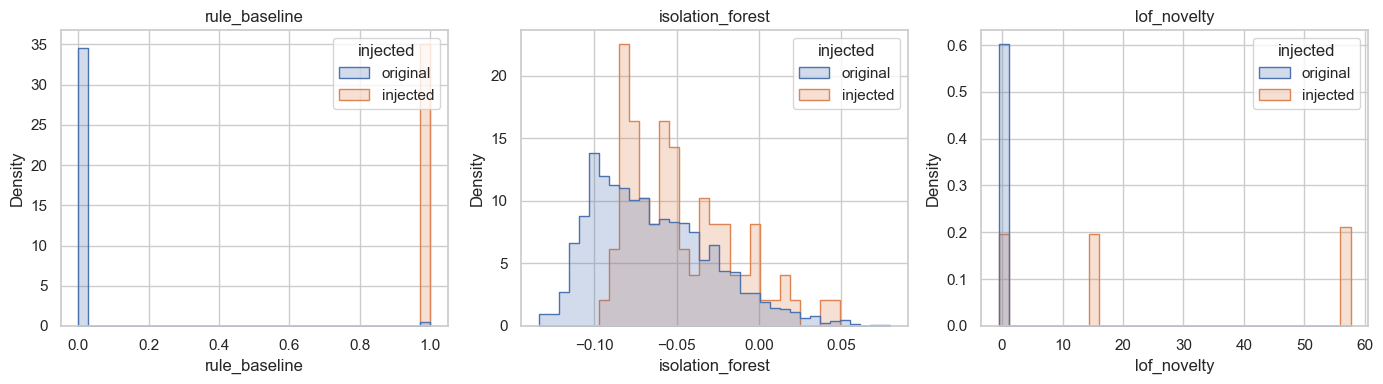

In [8]:
plot_data = score_frame.assign(
    injected=np.where(anomaly_label == 1, "injected", "original")
)

fig, axes = plt.subplots(1, len(score_frame.columns), figsize=(14, 4))
for ax, name in zip(axes, score_frame.columns):
    sns.histplot(
        data=plot_data,
        x=name,
        hue="injected",
        bins=35,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    ax.set_title(name)
plt.tight_layout()

## Interpretation

Use the table and histograms together:

- If injected and original score distributions separate clearly, the method is useful for this controlled problem.
- If a complex detector only matches the rule baseline, the simple baseline may be the better operational choice.
- If the model finds many original rows with high scores, review examples before calling them errors.

A good production recommendation should consider performance, simplicity, speed, stability, and whether humans can act on the alert.

In [9]:
best_method = evaluation.iloc[0]["method"]
best_scores = scores[best_method]
top_review = contaminated.copy()
top_review["anomaly_score"] = best_scores
top_review["injected_anomaly"] = anomaly_label

top_review = top_review.sort_values("anomaly_score", ascending=False)
review_columns = ["anomaly_score", "injected_anomaly", "age", "campaign", "balance", "job", "education", "housing", "loan"]
top_review[review_columns].head(12)

,anomaly_score,injected_anomaly,age,campaign,balance,job,education,housing,loan
1768,57.625503,1,60,8,1000000,retired,secondary,yes,no
613,57.625124,1,39,1,1000000,management,tertiary,no,no
2501,57.624974,1,30,3,1000000,admin.,secondary,yes,no
3307,57.624004,1,50,3,1000000,unemployed,secondary,no,no
2776,57.624003,1,41,6,1000000,technician,secondary,no,no
1460,57.623961,1,51,3,1000000,services,secondary,no,yes
2718,57.623669,1,37,1,1000000,management,tertiary,no,no
3836,57.623552,1,46,3,1000000,management,tertiary,yes,no
1405,57.623501,1,31,1,1000000,management,tertiary,yes,no
269,57.623341,1,35,5,1000000,management,tertiary,no,no


The top-ranked rows are the first rows a human reviewer would see. In a real system, this table should be paired with a review label such as `valid`, `data_error`, `duplicate`, `policy_exception`, or `needs_follow_up`.

**Teaching note:** Have students inspect the top original rows (`injected_anomaly == 0`). Ask: are they suspicious, merely rare, or artifacts of the score definition?

## Practical recommendation

For this controlled notebook, start with the rule baseline and Isolation Forest:

- The **rule baseline** is easiest to explain and maintain. It is strong for obvious field-level problems.
- **Isolation Forest** is a practical next step when anomalies may involve combinations of features or less obvious patterns.
- **LOF** can be useful for local-density problems, but it is usually more sensitive to representation, neighborhood size, and runtime.

Do not automatically delete or block high-scoring records. Use anomaly detection as a ranked triage tool, collect reviewer feedback, and retrain or recalibrate only after the review process is reliable.

## Common mistakes and leakage warnings

- Calling the positive supervised class an anomaly merely because it is rare.
- Fitting preprocessing on validation or test data.
- Evaluating an outlier detector on the same rows used for fitting.
- Using default LOF training-outlier mode when the goal is to score future rows.
- Optimizing only a metric while ignoring review cost, interpretability, and deployment speed.
- Removing anomalies before checking whether they are valid rare business cases.

## Exercises

1. Change the review budget from `k` injected anomalies to a fixed budget such as 50 rows. How does the recommendation change?
2. Inject subtler multivariate anomalies that keep each feature inside its normal range.
3. Tune `n_neighbors` for LOF and compare both precision@k and runtime.
4. **Challenge:** Add a reviewer-label column for the top 30 original rows and design a process to measure alert usefulness without verification bias.
5. Write a short deployment policy: who reviews alerts, what actions are allowed, and when the detector should be retrained.

## Summary

Anomaly detection is a ranking workflow, not a magic fraud labeler. A clear operational definition, leakage-safe preprocessing, simple baselines, honest validation, and human review are more important than using the most sophisticated detector.

## References

- [scikit-learn IsolationForest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html)
- [scikit-learn LocalOutlierFactor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html)
- [scikit-learn outlier and novelty detection guide](https://scikit-learn.org/stable/modules/outlier_detection.html)